<a href="https://colab.research.google.com/github/hhuang45/OmicSelector/blob/master/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-learn pandas numpy matplotlib seaborn

 Demonstrating on Iris Dataset (Classification & Clustering) 

--- 1. Data Overview ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target: ['setosa' 'versicolor' 'virginica']


--- 2. K-Means Clustering (Unsupervised) ---


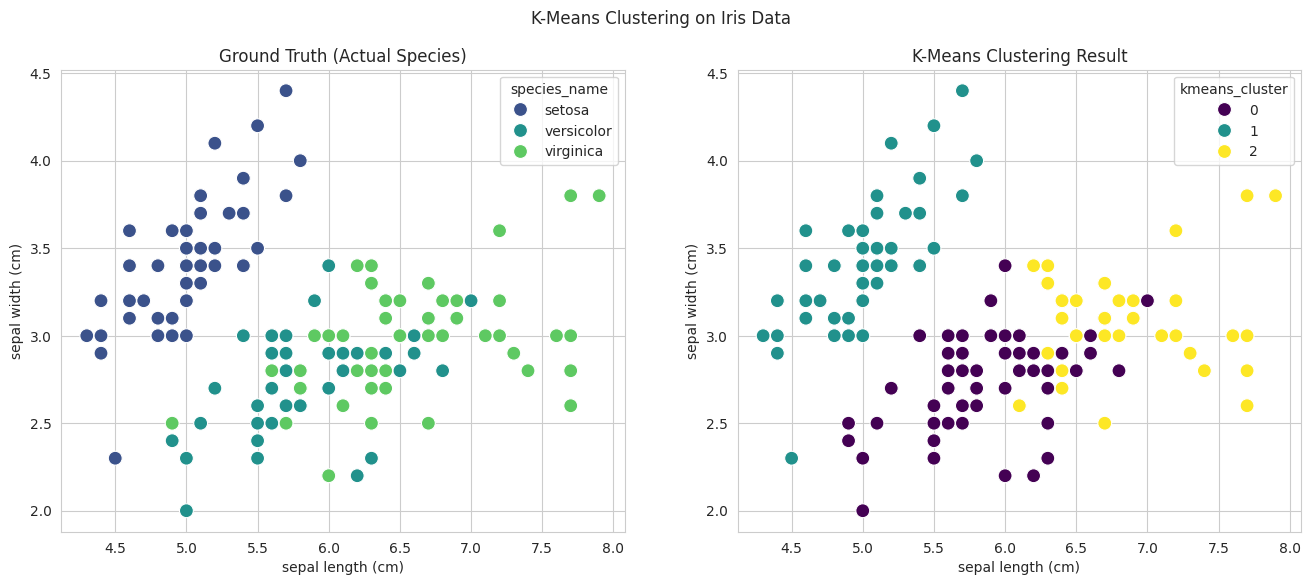



--- 3. Supervised Classification Models ---

--- Training and Evaluating: Decision Tree ---
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


--- Training and Evaluating: Bagging (Ensemble) ---
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


--- Traini

/tmp/ipython-input-4-3322410447.py:134: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mpg_df = pd.read_csv(url, names=column_names, na_values="?", comment='\t',



--- 1. Data Overview (after cleaning and encoding) ---
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year     1      2      3  
0          70  True  False  False  
1          70  True  False  False  
2          70  True  False  False  
3          70  True  False  False  
4          70  True  False  False  


--- 2. K-Means Clustering (Unsupervised) ---


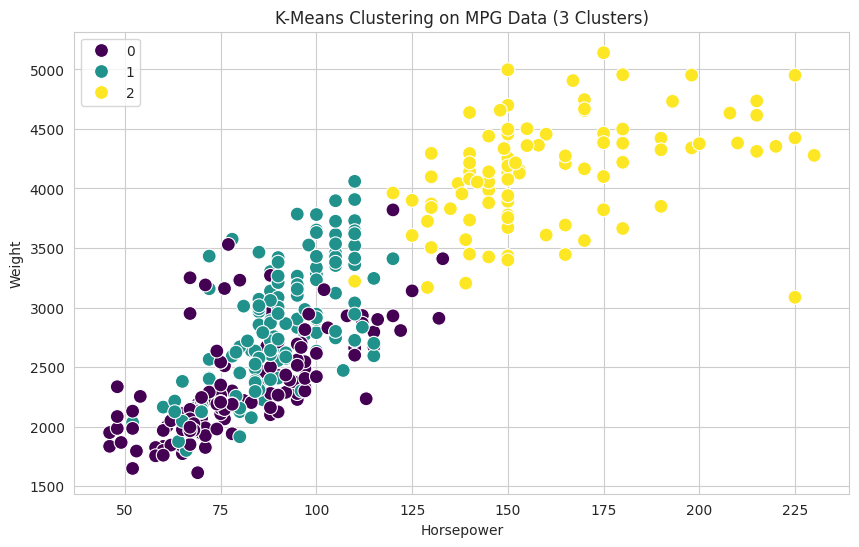



--- 3. Supervised Regression Models ---

--- Training and Evaluating: Decision Tree ---
Mean Squared Error (MSE): 12.6478
R-squared (R2 Score): 0.7609

--- Training and Evaluating: Bagging (Ensemble) ---
Mean Squared Error (MSE): 6.7703
R-squared (R2 Score): 0.8720

--- Training and Evaluating: Random Forest (Ensemble) ---
Mean Squared Error (MSE): 6.8500
R-squared (R2 Score): 0.8705

--- Training and Evaluating: Gradient Boosting (Ensemble) ---
Mean Squared Error (MSE): 7.9722
R-squared (R2 Score): 0.8493


--- 4. Regression Model Comparison (R2 Score) ---
Bagging (Ensemble)          : 0.8720
Random Forest (Ensemble)    : 0.8705
Gradient Boosting (Ensemble): 0.8493
Decision Tree               : 0.7609


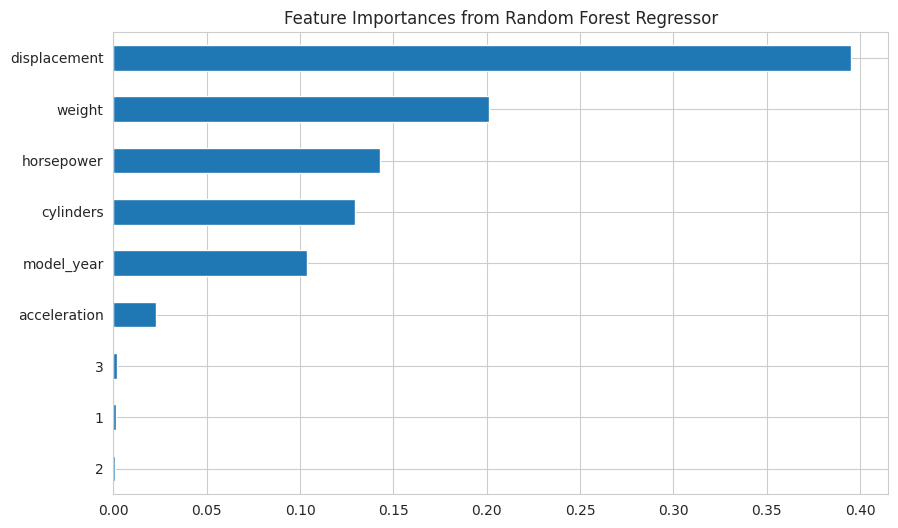

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & Splitting ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Models ---
# Unsupervised
from sklearn.cluster import KMeans
# Supervised
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# --- Evaluation Metrics ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score


# Set plot style
sns.set_style("whitegrid")

# ==============================================================================
# PART 1: IRIS DATASET (Classification & Clustering)
# ==============================================================================

def demonstrate_on_iris():
    """
    Loads the Iris dataset and demonstrates K-Means, Decision Tree,
    and Ensemble methods for classification.
    """
    print("="*60)
    print(" Demonstrating on Iris Dataset (Classification & Clustering) ")
    print("="*60)

    # 1. Load and Prepare Data
    from sklearn.datasets import load_iris
    iris = load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    target_names = iris.target_names

    # Create a DataFrame for easier visualization
    iris_df = pd.DataFrame(X, columns=feature_names)
    iris_df['species'] = y
    iris_df['species_name'] = iris_df['species'].map({i: name for i, name in enumerate(target_names)})

    print("\n--- 1. Data Overview ---")
    print(iris_df.head())
    print(f"\nFeatures: {feature_names}")
    print(f"Target: {target_names}")

    # --- 2. K-Means Clustering (Unsupervised) ---
    # Note: We use the full dataset 'X' as clustering is unsupervised.
    # We know there are 3 species, so we set n_clusters=3.
    print("\n\n--- 2. K-Means Clustering (Unsupervised) ---")
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_

    # Visualize the clustering results vs the ground truth
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Ground Truth
    # CHANGED: Added data=iris_df and used column names as strings.
    sns.scatterplot(ax=axes[0], data=iris_df, x='sepal length (cm)', y='sepal width (cm)',
                    hue='species_name', palette='viridis', s=100)
    axes[0].set_title('Ground Truth (Actual Species)')

    # K-Means Clustering
    iris_df['kmeans_cluster'] = cluster_labels
    # FIXED: Added data=iris_df and used column names as strings.
    sns.scatterplot(ax=axes[1], data=iris_df, x='sepal length (cm)', y='sepal width (cm)',
                    hue='kmeans_cluster', palette='viridis', s=100)
    axes[1].set_title('K-Means Clustering Result')

    plt.suptitle("K-Means Clustering on Iris Data")
    plt.show()

    # --- 3. Supervised Learning Models (Classification) ---
    # Split data for training and testing supervised models
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Bagging (Ensemble)": BaggingClassifier(DecisionTreeClassifier(random_state=42), n_estimators=50, random_state=42),
        "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=50, random_state=42),
        "Gradient Boosting (Ensemble)": GradientBoostingClassifier(n_estimators=50, random_state=42)
    }

    print("\n\n--- 3. Supervised Classification Models ---")
    for name, model in models.items():
        print(f"\n--- Training and Evaluating: {name} ---")

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Evaluate the model
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=target_names)

        print(f"Accuracy: {accuracy:.4f}")
        print("Classification Report:")
        print(report)

# ==============================================================================
# PART 2: AUTO MPG DATASET (Regression & Clustering)
# ==============================================================================

# Corrected 'demonstrate_on_mpg' function
def demonstrate_on_mpg():
    """
    Loads the Auto MPG dataset and demonstrates K-Means, Decision Tree,
    and Ensemble methods for regression.
    """
    print("\n\n" + "="*60)
    print(" Demonstrating on Auto MPG Dataset (Regression & Clustering) ")
    print("="*60)

    # 1. Load and Prepare Data
    url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
    column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                    'acceleration', 'model_year', 'origin', 'car_name']

    # FIXED: Use delim_whitespace=True for robust parsing of the data file.
    mpg_df = pd.read_csv(url, names=column_names, na_values="?", comment='\t',
                         delim_whitespace=True)

    # --- Data Cleaning ---
    # Now this will only drop rows where 'horsepower' is genuinely missing.
    mpg_df = mpg_df.dropna()
    mpg_df = mpg_df.drop('car_name', axis=1)

    # One-hot encode the 'origin' categorical feature
    mpg_df = pd.get_dummies(mpg_df, columns=['origin'], prefix='', prefix_sep='')

    print("\n--- 1. Data Overview (after cleaning and encoding) ---")
    print(mpg_df.head())

    # Separate features and target
    X = mpg_df.drop('mpg', axis=1)
    y = mpg_df['mpg']

    # --- 2. K-Means Clustering (Unsupervised) ---
    print("\n\n--- 2. K-Means Clustering (Unsupervised) ---")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Let's try to find 3 clusters of cars
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    cluster_labels = kmeans.labels_

    # Visualize clustering results
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X['horsepower'], y=X['weight'], hue=cluster_labels, palette='viridis', s=100)
    plt.title('K-Means Clustering on MPG Data (3 Clusters)')
    plt.xlabel('Horsepower')
    plt.ylabel('Weight')
    plt.show()

    # --- 3. Supervised Learning Models (Regression) ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Bagging (Ensemble)": BaggingRegressor(DecisionTreeRegressor(random_state=42), n_estimators=50, random_state=42),
        "Random Forest (Ensemble)": RandomForestRegressor(n_estimators=50, random_state=42),
        "Gradient Boosting (Ensemble)": GradientBoostingRegressor(n_estimators=50, random_state=42)
    }

    print("\n\n--- 3. Supervised Regression Models ---")
    results = {}
    for name, model in models.items():
        print(f"\n--- Training and Evaluating: {name} ---")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[name] = r2

        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"R-squared (R2 Score): {r2:.4f}")

    # --- 4. Comparing Model Performance ---
    print("\n\n--- 4. Regression Model Comparison (R2 Score) ---")
    for name, r2 in sorted(results.items(), key=lambda item: item[1], reverse=True):
        print(f"{name:<28}: {r2:.4f}")

    rf_model = models["Random Forest (Ensemble)"]
    importances = pd.Series(rf_model.feature_importances_, index=X.columns)

    plt.figure(figsize=(10, 6))
    importances.sort_values().plot(kind='barh')
    plt.title('Feature Importances from Random Forest Regressor')
    plt.show()

if __name__ == "__main__":
    demonstrate_on_iris()
    demonstrate_on_mpg()

Explanation of the Code
Part 1: Iris Dataset (Classification & Clustering)
Data Loading: We load the famous Iris dataset from sklearn.datasets. It's a simple dataset with 4 features (sepal length/width, petal length/width) and a target of 3 species.
K-Means Clustering:
This is an unsupervised algorithm, meaning it finds patterns without using the target labels (y).
We initialize KMeans with n_clusters=3 because we know there are three species. In a real-world scenario, you might use techniques like the "elbow method" to find the optimal number of clusters.
The model is fit to the feature data X.
The visualization compares the ground truth (the actual species) with the clusters found by K-Means. You can see K-Means does a great job of separating the species, even without being told what they were.
Supervised Classification:
Data Split: The data is split into training (70%) and testing (30%) sets. This is crucial for evaluating how well a model generalizes to new, unseen data. stratify=y ensures the proportion of species is the same in both the train and test sets.
Decision Tree: A single decision tree is trained. It's simple and interpretable but can be prone to overfitting.
Bagging (Bootstrap Aggregating): This is an ensemble method. It creates multiple Decision Trees on different random subsets (with replacement) of the training data. The final prediction is made by averaging (or voting on) the predictions of all trees. This reduces variance and overfitting. BaggingClassifier takes a base estimator, which we set to a DecisionTreeClassifier.
Random Forest: This is an enhancement of Bagging. In addition to sampling the data, it also samples the features at each split in the tree. This further de-correlates the trees, often leading to a more robust model.
Gradient Boosting: This is a different type of ensemble method. It builds trees sequentially, where each new tree tries to correct the errors made by the previous ones. It's often one of the highest-performing "off-the-shelf" algorithms.
Evaluation: For each model, we calculate accuracy and a classification_report, which provides more detailed metrics like precision, recall, and F1-score for each class.
Part 2: Auto MPG Dataset (Regression & Clustering)
Data Loading & Prep:
The data is loaded from the UCI repository using pandas.
Cleaning: The dataset has missing values marked as ?, which are handled by dropna(). The car_name is removed as it's a unique identifier, not a useful feature.
Encoding: The origin column is categorical (1: USA, 2: Europe, 3: Japan). Machine learning models need numerical input, so we use pd.get_dummies to perform one-hot encoding, converting it into three separate binary columns.
K-Means Clustering:
Scaling: Unlike Iris, the features in the MPG dataset have very different scales (e.g., weight is in thousands, cylinders is a small integer). K-Means is a distance-based algorithm, so features with larger scales can dominate. We use StandardScaler to give all features a mean of 0 and a standard deviation of 1, ensuring they are treated equally.
We again choose n_clusters=3 to see if the algorithm can find meaningful groups (e.g., small efficient cars, medium sedans, large gas-guzzlers). The plot shows the resulting clusters based on horsepower and weight.
Supervised Regression:
The task here is to predict a continuous value (mpg) rather than a category.
The same set of models are used, but this time we use their regressor versions (e.g., DecisionTreeRegressor, RandomForestRegressor).
Evaluation: The metrics are different for regression:
Mean Squared Error (MSE): The average of the squared differences between the actual and predicted values. Lower is better.
R-squared (R² Score): Represents the proportion of the variance in the target variable that is predictable from the features. A score of 1.0 is a perfect prediction. Higher is better.
Comparison and Feature Importance:
We print a summary of the R² scores, showing that the ensemble methods (Random Forest and Gradient Boosting) typically outperform the single Decision Tree.
A key advantage of tree-based ensembles like Random Forest is the ability to calculate feature importance. The final plot shows which features the model found most predictive for determining a car's MPG. Unsurprisingly, weight, displacement, and horsepower are very important.
